In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import matplotlib.pyplot as plt

import joblib

In [3]:
api_features = pd.read_csv(
    "/content/drive/MyDrive/Cloud anomaly detection/processed dataset/api_features.csv"
)

In [4]:
print(api_features.shape)

api_features.head()

(6851, 9)


,sourceIPAddress,request_count,unique_events,unique_services,error_count,unique_users,unique_regions,unique_agents,error_rate
0,0.0,0.399438,17.108667,15.108641,0.308647,2.421678,0.341116,5.336238,2.119361
1,0.1,-0.016885,-0.078182,0.105260,-0.014836,-0.565254,-0.060014,0.336297,-0.183077
2,0.101,-0.021019,-0.192570,-0.311501,-0.015196,-0.565254,-0.461145,-0.663691,-0.467408
3,0.102,-0.015467,0.150595,0.244180,-0.014356,0.928212,-0.060014,0.336297,0.030171
4,0.109,-0.020665,-0.106779,-0.172581,-0.015196,-0.565254,-0.060014,-0.663691,-0.467408


In [5]:
api_features.columns.tolist()

['sourceIPAddress',
 'request_count',
 'unique_events',
 'unique_services',
 'error_count',
 'unique_users',
 'unique_regions',
 'unique_agents',
 'error_rate']

In [6]:
api_features.isnull().sum()

,0
sourceIPAddress,0
request_count,0
unique_events,0
unique_services,0
error_count,0
unique_users,0
unique_regions,0
unique_agents,0
error_rate,0


In [7]:
X_api = api_features.drop(
    columns=['sourceIPAddress']
)

In [8]:
print(X_api.shape)

(6851, 8)


In [9]:
X_api.describe()

,request_count,unique_events,unique_services,error_count,unique_users,unique_regions,unique_agents,error_rate
count,6.851000e+03,6.851000e+03,6.851000e+03,6.851000e+03,6.851000e+03,6.851000e+03,6.851000e+03,6.851000e+03
mean,4.978259e-17,3.111412e-17,1.866847e-17,6.533965e-17,2.489129e-17,3.318839e-17,-1.244565e-16,1.286050e-16
std,1.000073e+00,1.000073e+00,1.000073e+00,1.000073e+00,1.000073e+00,1.000073e+00,1.000073e+00,1.000073e+00
min,-2.101940e-02,-1.925701e-01,-3.115008e-01,-1.519599e-02,-5.652545e-01,-4.611454e-01,-6.636909e-01,-4.674078e-01
25%,-2.101940e-02,-1.925701e-01,-3.115008e-01,-1.519599e-02,-5.652545e-01,-4.611454e-01,-6.636909e-01,-4.674078e-01
50%,-2.078312e-02,-1.639730e-01,-1.725806e-01,-1.519599e-02,-5.652545e-01,-6.001448e-02,-6.636909e-01,-4.674078e-01
75%,-1.830219e-02,-7.818179e-02,-3.366042e-02,-1.507601e-02,9.282119e-01,-6.001448e-02,3.362973e-01,-1.830773e-01
max,8.223808e+01,2.305686e+01,2.024869e+01,8.266431e+01,6.902078e+00,5.956950e+00,2.233604e+01,2.944558e+00


In [10]:
iso_api = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_api.fit(X_api)

IsolationForest(contamination=0.05, random_state=42)

In [11]:
api_features['if_anomaly'] = iso_api.predict(X_api)

In [12]:
api_features['if_anomaly'].value_counts()

,count
if_anomaly,
1,6508
-1,343


In [13]:
api_features['if_anomaly'].value_counts(normalize=True)

,proportion
if_anomaly,
1,0.949934
-1,0.050066


In [14]:
api_features['if_score'] = iso_api.decision_function(X_api)

In [15]:
api_features[['if_anomaly',
              'if_score']].head()

,if_anomaly,if_score
0,-1,-0.255891
1,1,0.172016
2,1,0.244491
3,1,0.138728
4,1,0.160713


In [16]:
api_features['if_score'].describe()

,if_score
count,6851.000000
mean,0.168804
std,0.089881
min,-0.269967
25%,0.124618
50%,0.190275
75%,0.244491
max,0.244491


In [17]:
lof_api = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)

In [18]:
lof_api.fit(X_api)

api_features['lof_anomaly'] = lof_api.predict(
    X_api
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [19]:
api_features['lof_anomaly'].value_counts()

,count
lof_anomaly,
1,6522
-1,329


In [20]:
api_features['lof_anomaly'].value_counts(
    normalize=True
)

,proportion
lof_anomaly,
1,0.951978
-1,0.048022


In [22]:
print(api_features.columns.tolist())

['sourceIPAddress', 'request_count', 'unique_events', 'unique_services', 'error_count', 'unique_users', 'unique_regions', 'unique_agents', 'error_rate', 'if_anomaly', 'if_score', 'lof_anomaly']


In [24]:
api_features['lof_score'] = lof_api.score_samples(
    X_api
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [25]:
api_features['lof_score'].describe()

,lof_score
count,6.851000e+03
mean,-1.528592e+06
std,3.801726e+07
min,-1.609607e+09
25%,-1.146805e+00
50%,-1.000000e+00
75%,-1.000000e+00
max,-9.091765e-01


In [26]:
api_features[
    [
        'lof_anomaly',
        'lof_score'
    ]
].head()

,lof_anomaly,lof_score
0,1,-1.005077
1,1,-1.133007
2,1,-1.000000
3,1,-1.209163
4,-1,-32.433447


In [27]:
api_features['lof_score'].nsmallest(10)

,lof_score
896,-1.609607e+09
1664,-1.347414e+09
2358,-1.282932e+09
133,-9.918133e+08
2800,-9.918133e+08
5513,-9.918133e+08
1114,-6.036037e+08
838,-3.646488e+08
1543,-2.574504e+08
49,-2.574450e+08


In [ ]:
api_features['lof_score'].nlargest(10)

In [28]:
api_features['lof_score'].quantile(
    [0.90,0.95,0.99,0.999]
)

,lof_score
0.900,-0.996861
0.950,-0.985938
0.990,-0.953102
0.999,-0.926723


In [29]:
(api_features['lof_score'] < -100).sum()

np.int64(242)

In [30]:
api_features['final_anomaly'] = np.where(
    (api_features['if_anomaly'] == -1) |
    (api_features['lof_anomaly'] == -1),
    1,
    0
)

In [31]:
api_features['final_anomaly'].value_counts()

,count
final_anomaly,
0,6189
1,662


In [32]:
api_features['final_anomaly'].value_counts(
    normalize=True
)

,proportion
final_anomaly,
0,0.903372
1,0.096628


In [33]:
api_features['lof_rank'] = (
    api_features['lof_score']
    .rank(method='dense', ascending=True)
)

In [35]:
from sklearn.preprocessing import MinMaxScaler

rank_scaler = MinMaxScaler()

api_features['lof_normalized'] = (
    rank_scaler.fit_transform(
        api_features[['lof_rank']]
    )
)

In [36]:
api_features['risk_score'] = (
    0.5 * api_features['lof_normalized']
    +
    0.5 * api_features['final_anomaly']
)

In [37]:
api_features[
    [
        'final_anomaly',
        'risk_score'
    ]
].describe()

,final_anomaly,risk_score
count,6851.000000,6851.000000
mean,0.096628,0.394747
std,0.295472,0.143312
min,0.000000,0.032903
25%,0.000000,0.382519
50%,0.000000,0.422285
75%,0.000000,0.422285
max,1.000000,0.999798


In [38]:
api_features.sort_values(
    'risk_score',
    ascending=False
)[
    [
        'sourceIPAddress',
        'risk_score',
        'final_anomaly'
    ]
].head(20)

,sourceIPAddress,risk_score,final_anomaly
604,121.54,0.999798,1
6340,80.8,0.999394,1
3108,227.119,0.998183,1
4591,254.78,0.996568,1
5416,5.165,0.996568,1
27,0.18,0.994954,1
5074,39.206,0.990916,1
1163,152.54,0.987687,1
5150,4.251,0.985870,1
3818,248.7,0.985466,1


In [39]:
api_features[
    [
        'final_anomaly',
        'risk_score'
    ]
].describe()

,final_anomaly,risk_score
count,6851.000000,6851.000000
mean,0.096628,0.394747
std,0.295472,0.143312
min,0.000000,0.032903
25%,0.000000,0.382519
50%,0.000000,0.422285
75%,0.000000,0.422285
max,1.000000,0.999798


In [40]:
api_features.sort_values(
    'risk_score',
    ascending=False
)[
    [
        'sourceIPAddress',
        'risk_score',
        'final_anomaly'
    ]
].head(10)

,sourceIPAddress,risk_score,final_anomaly
604,121.54,0.999798,1
6340,80.8,0.999394,1
3108,227.119,0.998183,1
4591,254.78,0.996568,1
5416,5.165,0.996568,1
27,0.18,0.994954,1
5074,39.206,0.990916,1
1163,152.54,0.987687,1
5150,4.251,0.985870,1
3818,248.7,0.985466,1


In [41]:
api_anomalies = api_features[
    [
        'sourceIPAddress',
        'if_anomaly',
        'if_score',
        'lof_anomaly',
        'lof_score',
        'final_anomaly',
        'risk_score'
    ]
]

In [42]:
api_anomalies.head()

,sourceIPAddress,if_anomaly,if_score,lof_anomaly,lof_score,final_anomaly,risk_score
0,0.0,-1,-0.255891,1,-1.005077,1,0.915624
1,0.1,1,0.172016,1,-1.133007,0,0.298143
2,0.101,1,0.244491,1,-1.000000,0,0.422285
3,0.102,1,0.138728,1,-1.209163,0,0.251918
4,0.109,1,0.160713,-1,-32.433447,1,0.523617


In [43]:
api_anomalies.shape

(6851, 7)

In [44]:
api_anomalies['final_anomaly'].value_counts()

,count
final_anomaly,
0,6189
1,662


In [45]:
total_rows = len(api_features)

if_anomalies = (api_features['if_anomaly'] == -1).sum()

lof_anomalies = (api_features['lof_anomaly'] == -1).sum()

ensemble_anomalies = (
    api_features['final_anomaly'] == 1
).sum()

print("API Dataset Summary")
print("-" * 40)

print(f"Rows: {total_rows}")

print(f"\nIsolation Forest anomalies:")
print(f"{if_anomalies} ({100*if_anomalies/total_rows:.2f}%)")

print(f"\nLOF anomalies:")
print(f"{lof_anomalies} ({100*lof_anomalies/total_rows:.2f}%)")

print(f"\nEnsemble anomalies:")
print(f"{ensemble_anomalies} ({100*ensemble_anomalies/total_rows:.2f}%)")

API Dataset Summary
----------------------------------------
Rows: 6851

Isolation Forest anomalies:
343 (5.01%)

LOF anomalies:
329 (4.80%)

Ensemble anomalies:
662 (9.66%)


In [46]:
summary_df = pd.DataFrame({
    'Model': [
        'Isolation Forest',
        'LOF',
        'Ensemble'
    ],
    'Anomalies': [
        if_anomalies,
        lof_anomalies,
        ensemble_anomalies
    ]
})

summary_df['Percentage'] = (
    summary_df['Anomalies']
    /
    total_rows
    * 100
)

summary_df

,Model,Anomalies,Percentage
0,Isolation Forest,343,5.006568
1,LOF,329,4.802219
2,Ensemble,662,9.662823


In [47]:
import os

results_dir = (
    "/content/drive/MyDrive/"
    "Cloud anomaly detection/results/API"
)

os.makedirs(
    results_dir,
    exist_ok=True
)

print("Created:", results_dir)

Created: /content/drive/MyDrive/Cloud anomaly detection/results/API


In [48]:
models_dir = (
    "/content/drive/MyDrive/"
    "Cloud anomaly detection/models/API"
)

os.makedirs(
    models_dir,
    exist_ok=True
)

print("Created:", models_dir)

Created: /content/drive/MyDrive/Cloud anomaly detection/models/API


In [49]:
print("Created:", models_dir)

Created: /content/drive/MyDrive/Cloud anomaly detection/models/API


In [50]:
joblib.dump(
    iso_api,
    f"{models_dir}/api_if.pkl"
)

joblib.dump(
    lof_api,
    f"{models_dir}/api_lof.pkl"
)

print("API models saved successfully")

API models saved successfully


In [51]:
loaded_if = joblib.load(
    f"{models_dir}/api_if.pkl"
)

loaded_lof = joblib.load(
    f"{models_dir}/api_lof.pkl"
)

print(type(loaded_if))
print(type(loaded_lof))

<class 'sklearn.ensemble._iforest.IsolationForest'>
<class 'sklearn.neighbors._lof.LocalOutlierFactor'>


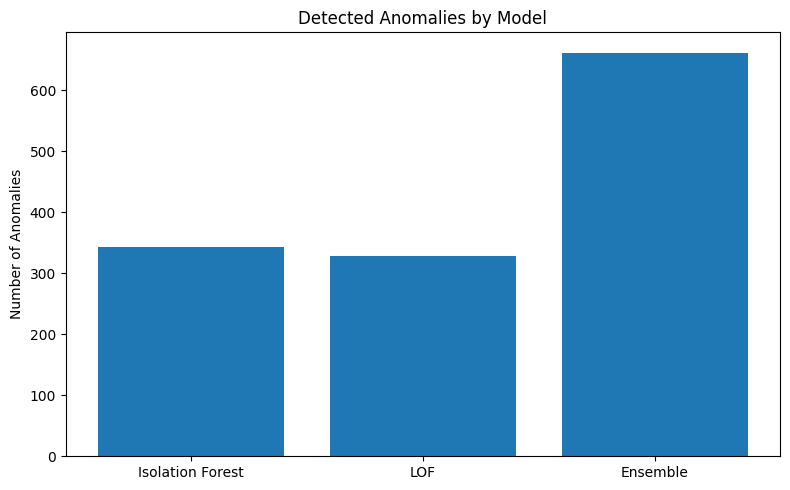

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    summary_df['Model'],
    summary_df['Anomalies']
)

plt.title('Detected Anomalies by Model')
plt.ylabel('Number of Anomalies')

plt.tight_layout()

plt.savefig(
    f"{results_dir}/Figure_1_Anomaly_Comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

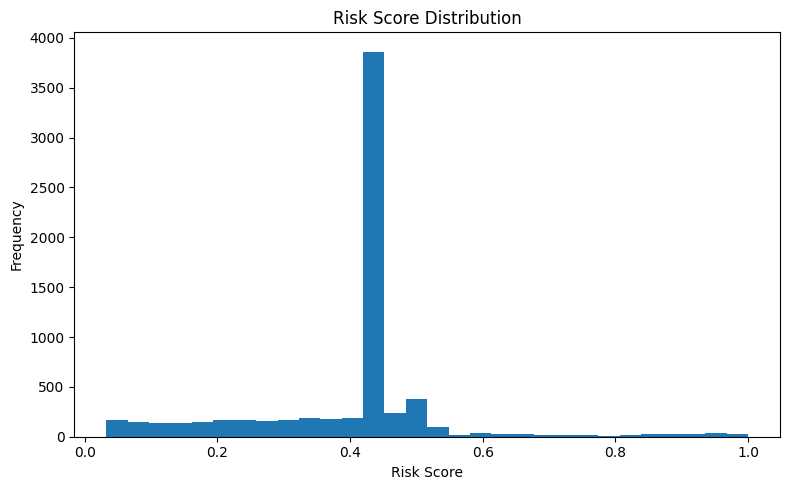

In [53]:
plt.figure(figsize=(8,5))

plt.hist(
    api_features['risk_score'],
    bins=30
)

plt.title('Risk Score Distribution')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    f"{results_dir}/Figure_2_Risk_Score_Distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

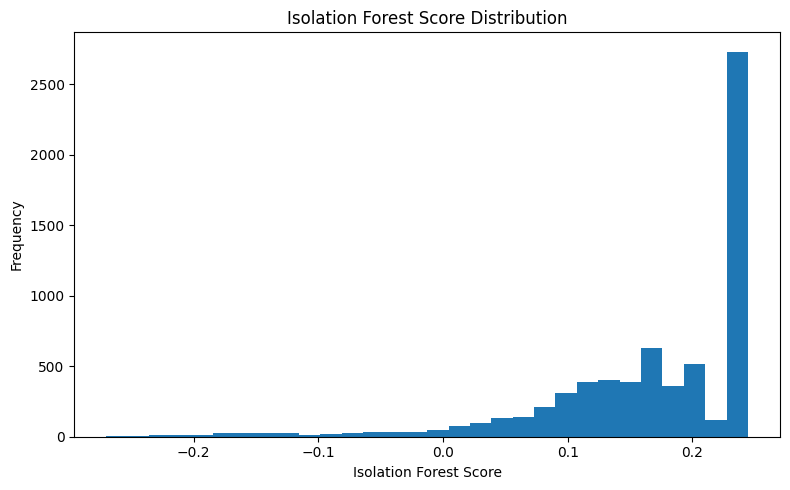

In [54]:
plt.figure(figsize=(8,5))

plt.hist(
    api_features['if_score'],
    bins=30
)

plt.title('Isolation Forest Score Distribution')
plt.xlabel('Isolation Forest Score')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    f"{results_dir}/Figure_3_IF_Score_Distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [55]:
top20 = (
    api_features
    .sort_values(
        'lof_score'
    )
    .head(20)
)

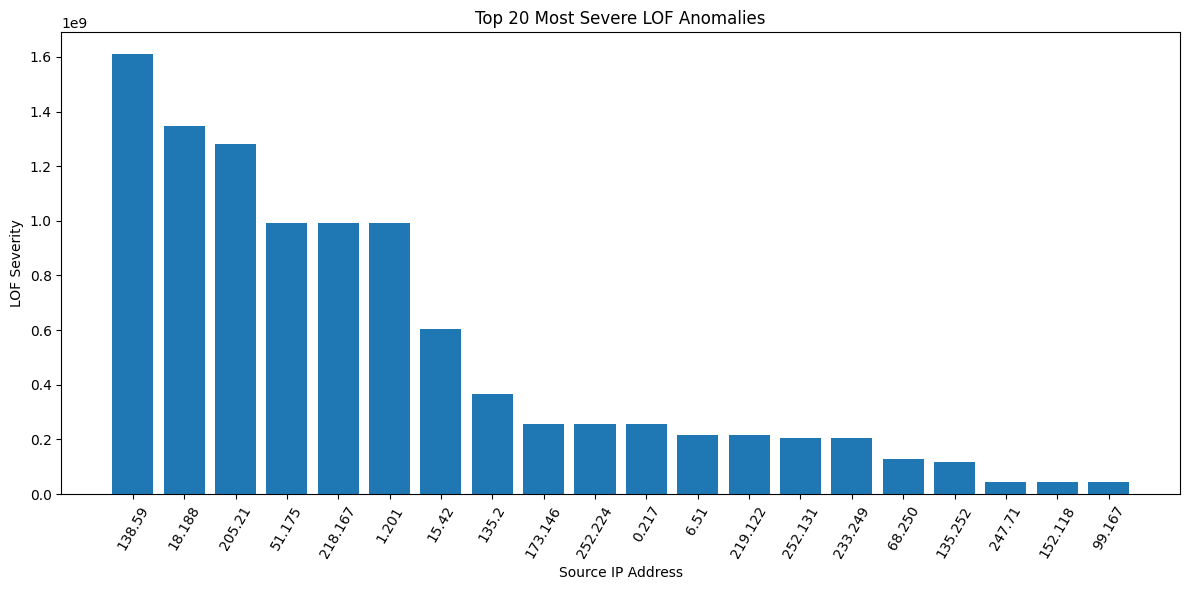

In [56]:
plt.figure(figsize=(12,6))

plt.bar(
    top20['sourceIPAddress'].astype(str),
    -top20['lof_score']
)

plt.title(
    'Top 20 Most Severe LOF Anomalies'
)

plt.xlabel('Source IP Address')
plt.ylabel('LOF Severity')

plt.xticks(rotation=60)

plt.tight_layout()

plt.savefig(
    f"{results_dir}/Figure_4_Top20_LOF_Anomalies.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

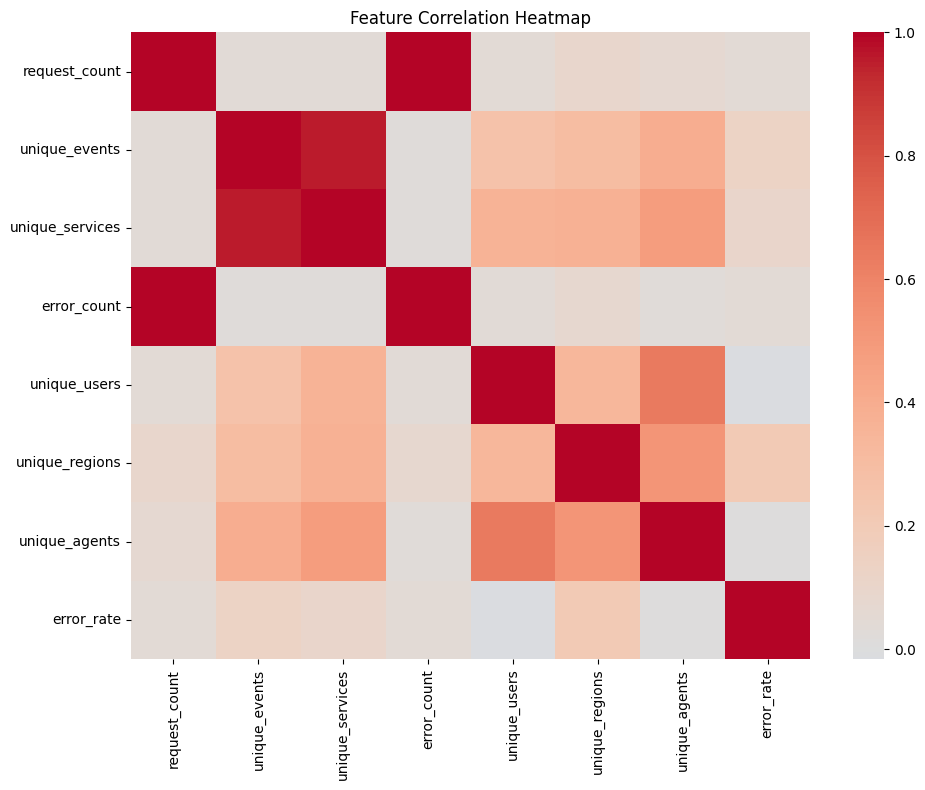

In [57]:
import seaborn as sns

plt.figure(figsize=(10,8))

corr = X_api.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Heatmap')

plt.tight_layout()

plt.savefig(
    f"{results_dir}/Figure_5_Feature_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 800x500 with 0 Axes>

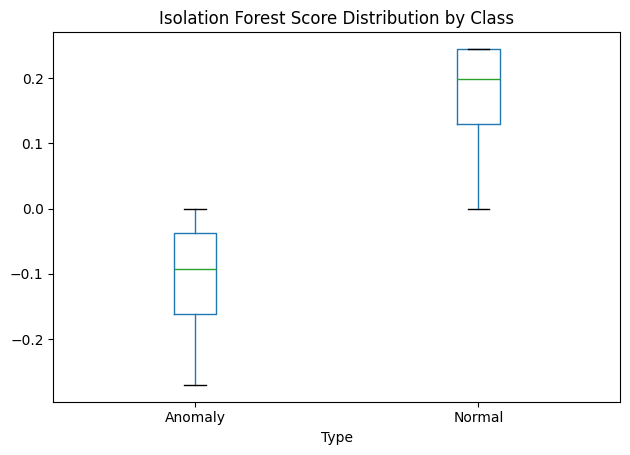

In [58]:
plt.figure(figsize=(8,5))

plot_df = pd.DataFrame({
    'IF Score': api_features['if_score'],
    'Type': np.where(
        api_features['if_anomaly']==-1,
        'Anomaly',
        'Normal'
    )
})

plot_df.boxplot(
    column='IF Score',
    by='Type',
    grid=False
)

plt.title('Isolation Forest Score Distribution by Class')
plt.suptitle('')

plt.tight_layout()

plt.savefig(
    f"{results_dir}/Figure_6_IF_Boxplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

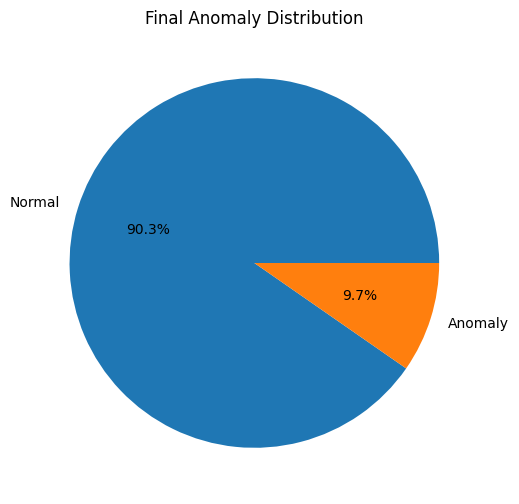

In [59]:
plt.figure(figsize=(6,6))

counts = api_features['final_anomaly'].value_counts()

plt.pie(
    [counts[0], counts[1]],
    labels=['Normal', 'Anomaly'],
    autopct='%1.1f%%'
)

plt.title('Final Anomaly Distribution')

plt.savefig(
    f"{results_dir}/Figure_7_anomaly_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [60]:
summary_df.to_csv(
    f"{results_dir}/api_results_summary.csv",
    index=False
)

api_anomalies.to_csv(
    f"{results_dir}/api_anomalies.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully


In [61]:
summary_text = f"""
==================================================
API ANOMALY DETECTION RESULTS
==================================================

Total Records: {total_rows}

Isolation Forest Anomalies:
{if_anomalies}

LOF Anomalies:
{lof_anomalies}

Final Ensemble Anomalies:
{ensemble_anomalies}

Anomaly Percentage:
{100 * ensemble_anomalies / total_rows:.2f} %

Files Generated:
1. api_anomalies.csv
2. api_results_summary.csv

Figures Generated:
1. Figure_1_Anomaly_Comparison.png
2. Figure_2_Risk_Score_Distribution.png
3. Figure_3_IF_Score_Distribution.png
4. Figure_4_Top20_LOF_Anomalies.png
5. Figure_5_Feature_Correlation_Heatmap.png
6. Figure_6_IF_Boxplot.png
7. Figure_7_anomaly_distribution.png

==================================================
"""

summary_file = f"{results_dir}/api_results_summary.txt"

with open(summary_file, "w") as f:
    f.write(summary_text)

print(summary_text)
print(f"\nSaved: {summary_file}")


API ANOMALY DETECTION RESULTS

Total Records: 6851

Isolation Forest Anomalies:
343

LOF Anomalies:
329

Final Ensemble Anomalies:
662

Anomaly Percentage:
9.66 %

Files Generated:
1. api_anomalies.csv
2. api_results_summary.csv

Figures Generated:
1. Figure_1_Anomaly_Comparison.png
2. Figure_2_Risk_Score_Distribution.png
3. Figure_3_IF_Score_Distribution.png
4. Figure_4_Top20_LOF_Anomalies.png
5. Figure_5_Feature_Correlation_Heatmap.png
6. Figure_6_IF_Boxplot.png
7. Figure_7_anomaly_distribution.png



Saved: /content/drive/MyDrive/Cloud anomaly detection/results/API/api_results_summary.txt
